# DeepExtractor — Training Tutorial

This notebook trains a fresh `DeepExtractor_257` (U-Net 2D) model from scratch on a small synthetic
PyCBC noise dataset, plots the training and validation losses, and then tests the trained model
on held-out sine-Gaussian injections.

**What PyCBC noise means here:** the background noise is white Gaussian noise scaled to match
the variance of a whitened PyCBC noise realization. It is not coloured detector noise —
use `--bilby-noise` / `bilby_noise=True` for that.

**Pipeline overview:**
1. Generate synthetic time-domain data (noisy glitch + background pairs)
2. Convert to STFT spectrograms (magnitude + phase)
3. Train the U-Net on spectrogram pairs
4. Plot losses
5. Test on sine-Gaussian injections

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from deepextractor.models.architectures import UNET2D
from deepextractor.generation.generate_timeseries import (
    generate_gaussian_noise, generate_synthetic_data, LENGTH, SAMPLE_RATE, T
)
from deepextractor.generation.glitch_functions import generate_sine_gaussian
from deepextractor.utils.signal import whitened_snr_scaling
from deepextractor.training.train_fn import train_fn
from deepextractor.utils.io import check_accuracy


## Configuration

In [2]:
# Device — uses MPS on Apple Silicon, CUDA on Linux/Windows GPU, otherwise CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# Dataset size — keep small for a quick demo; increase for real training
N_TRAIN = 1000
N_VAL   = 200

# Training
BATCH_SIZE              = 32
EPOCHS                  = 50    # maximum epochs; early stopping may stop sooner however, this specific architecture will likely converge at a much higher epoch
LR                      = 1e-4
LR_PATIENCE             = 4     # epochs without improvement before LR is reduced
LR_FACTOR               = 0.1   # factor to reduce LR by
EARLY_STOPPING_PATIENCE = 9     # epochs without improvement before training stops

# STFT parameters
# Original DeepExtractor (arXiv:2501.18423): N_FFT=512, WIN_LENGTH=64, HOP_LENGTH=32
# → produces (257, 257) spectrograms, richer time-frequency representation
#   but significantly slower to train.
# Tutorial default: smaller spectrograms for faster training, but still gives decent performance (please see 129x129 model in the paper).
N_FFT      = 256
WIN_LENGTH = N_FFT // 2
HOP_LENGTH = WIN_LENGTH // 2


Using device: mps


## Step 1 — Generate synthetic time-domain data

Each training sample is a pair:
- **Input** `glitch`: background noise with 1–30 synthetic signal injections (chirps, sine-Gaussians, etc.)
- **Target** `background`: the same noise without any injections

The model learns to map glitchy strain → clean background.

In [3]:
mean, std_dev = 0, np.sqrt(SAMPLE_RATE)

print("Generating training noise...")
train_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
print("Generating validation noise...")
val_noise   = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print("Generating training pairs...")
glitch_train, bg_train = generate_synthetic_data(train_noise, bilby_noise=False, phase="train")
print("Generating validation pairs...")
glitch_val,   bg_val   = generate_synthetic_data(val_noise,   bilby_noise=False, phase="val")

print(f"\nTrain: {glitch_train.shape}  |  Val: {glitch_val.shape}")

Generating training noise...
Generating pycbc noise...
Generating validation noise...
Generating pycbc noise...
Generating training pairs...


Generating Synthetic Train Data: 100%|██████████| 1000/1000 [00:02<00:00, 464.04it/s]


Generating validation pairs...


Generating Synthetic Val Data: 100%|██████████| 200/200 [00:00<00:00, 367.59it/s]


Train: (1000, 8192)  |  Val: (200, 8192)


## Step 2 — Scale and convert to spectrograms

In [4]:
scaler = StandardScaler()
glitch_train_scaled = scaler.fit_transform(glitch_train.reshape(-1, 1)).reshape(glitch_train.shape)
bg_train_scaled     = scaler.transform(bg_train.reshape(-1, 1)).reshape(bg_train.shape)
glitch_val_scaled   = scaler.transform(glitch_val.reshape(-1, 1)).reshape(glitch_val.shape)
bg_val_scaled       = scaler.transform(bg_val.reshape(-1, 1)).reshape(bg_val.shape)

# Uncomment to save the scaler for use outside this notebook
# import pickle, os
# os.makedirs('/tmp/de_training_tutorial', exist_ok=True)
# with open('/tmp/de_training_tutorial/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Convert to STFT spectrograms (in-memory)
window = torch.hann_window(WIN_LENGTH)

def to_mag_phase(arrays):
    """Convert a numpy array (N, time) to a (N, 2, F, T) mag/phase tensor."""
    t = torch.tensor(arrays, dtype=torch.float32)
    stft = torch.stft(t, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    return torch.stack([mag, phase], dim=1)  # (N, 2, F, T)

glitch_train_spec = to_mag_phase(glitch_train_scaled)
bg_train_spec     = to_mag_phase(bg_train_scaled)
glitch_val_spec   = to_mag_phase(glitch_val_scaled)
bg_val_spec       = to_mag_phase(bg_val_scaled)

print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")

# Uncomment to save spectrograms to disk (useful for large datasets or re-use)
# os.makedirs('/tmp/de_training_tutorial/spectrogram_domain', exist_ok=True)
# for name, arr in [
#     ('glitch_train_scaled_mag_phase',     glitch_train_spec.numpy()),
#     ('background_train_scaled_mag_phase', bg_train_spec.numpy()),
#     ('glitch_val_scaled_mag_phase',       glitch_val_spec.numpy()),
#     ('background_val_scaled_mag_phase',   bg_val_spec.numpy()),
# ]:
#     np.save(f'/tmp/de_training_tutorial/spectrogram_domain/{name}', arr)


Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 3 — Build model and data loaders

In [5]:
from torch.utils.data import TensorDataset, DataLoader

# Model architecture
# Original DeepExtractor (arXiv:2501.18423): features=[64, 128, 256, 512] — ~31M parameters.
# Use those to train a model equivalent to the published DeepExtractor.
# Tutorial default: one fewer layer and half the filters for faster training.
model = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_ds = TensorDataset(glitch_train_spec, bg_train_spec)
val_ds   = TensorDataset(glitch_val_spec,   bg_val_spec)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")


Model parameters: 7,762,786
Train batches: 32  |  Val batches: 7
Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 4 — Train

We train the network for up to `EPOCHS` iterations. For this minimal tutorial configuration
(1000 samples, reduced model), 50 epochs is sufficient to see the loss converge.
To train a model to full convergence, set `EPOCHS` to a large number (e.g. 200) — the learning rate
scheduler and early stopping will halt training automatically once the validation loss stops
improving. For longer runs, we recommend using a CUDA GPU (e.g. Google Colab).


In [6]:
loss_fn   = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
amp_scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu")

train_losses, val_losses = [], []
best_val_loss           = float("inf")
early_stopping_counter  = 0

for epoch in range(EPOCHS):
    train_loss, _, _ = train_fn(
        train_loader, model, "DeepExtractor_257", optimizer, loss_fn, amp_scaler, DEVICE
    )
    val_loss, _, _ = check_accuracy(val_loader, model, "DeepExtractor_257", device=DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  lr={current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

print("\nTraining complete.")


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  2.94it/s, loss=2.05]


Validation Loss: 2.265100
Epoch   1/50  train=2.43718  val=2.26510  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.05it/s, loss=1.67]


Validation Loss: 1.572487
Epoch   2/50  train=1.78313  val=1.57249  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.01it/s, loss=1.31]


...

Validation Loss: 0.526566
Epoch  48/50  train=0.51698  val=0.52657  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.44it/s, loss=0.51] 


Validation Loss: 0.524766
Epoch  49/50  train=0.51134  val=0.52477  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.31it/s, loss=0.565]


Validation Loss: 0.524385
Epoch  50/50  train=0.50923  val=0.52438  lr=1.0e-04

Training complete.


## Step 5 — Plot losses

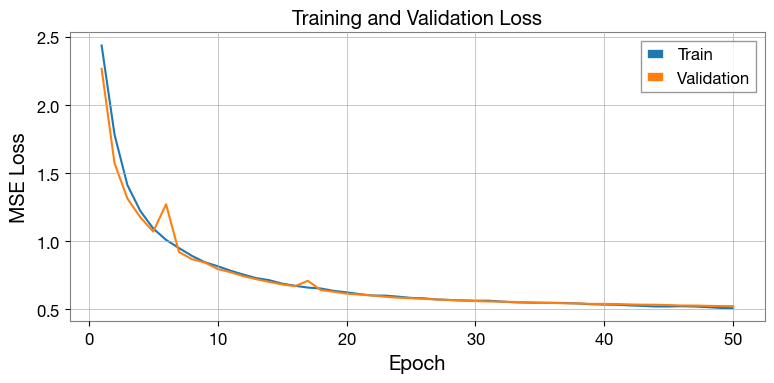

In [7]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train",      color="C0")
ax.plot(epochs_ran, val_losses,   label="Validation", color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Step 6 — Test on sine-Gaussian injections

We generate fresh test examples — PyCBC (numpy) noise with a sine-Gaussian injected at a range of SNRs —
and run them through the trained model.
The model was never trained on these specific examples.
We use three different test examples at three different SNRs, reporting the SNR and mismatch ($\mathcal{M}$) above each plot. 
Intuitively, the model better recovers louder glitches than quieter ones. 
The reconstructions below feature high-frequency artifacts as the model training did not fully converge, and it is a reduced architecture compared to the published version. 
Improved performance can be achieved by training this model until convergence or by modifying the layers of DeepExtractor's U-Net to the published architecture, and increasing the resolution of the STFT spectrograms (please see above).

In [8]:
def reconstruct(noisy_signal, model, scaler, device, n_fft, hop_length, win_length):
    """Scale → STFT → U-Net → iSTFT → unscale → subtract background."""
    # Scale
    scaled = scaler.transform(noisy_signal.reshape(-1, 1)).reshape(noisy_signal.shape)

    # STFT
    window = torch.hann_window(win_length)
    t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)  # (1, time)
    stft = torch.stft(t, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    spec  = torch.stack([mag, phase], dim=1)  # (1, 2, F, T)

    # U-Net inference
    model.eval()
    with torch.no_grad():
        bg_spec = model(spec.to(device)).cpu()  # predicted background spectrogram

    # iSTFT
    bg_mag   = bg_spec[:, 0, :, :]
    bg_phase = bg_spec[:, 1, :, :]
    bg_complex = bg_mag * torch.exp(1j * bg_phase)
    bg_td = torch.istft(bg_complex, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window,
                        length=noisy_signal.shape[-1])

    # Unscale and subtract background to recover signal
    bg_unscaled = scaler.inverse_transform(bg_td.numpy().reshape(-1, 1)).reshape(-1)
    noisy_unscaled = noisy_signal.copy()
    reconstruction = noisy_unscaled - bg_unscaled
    return reconstruction

Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...


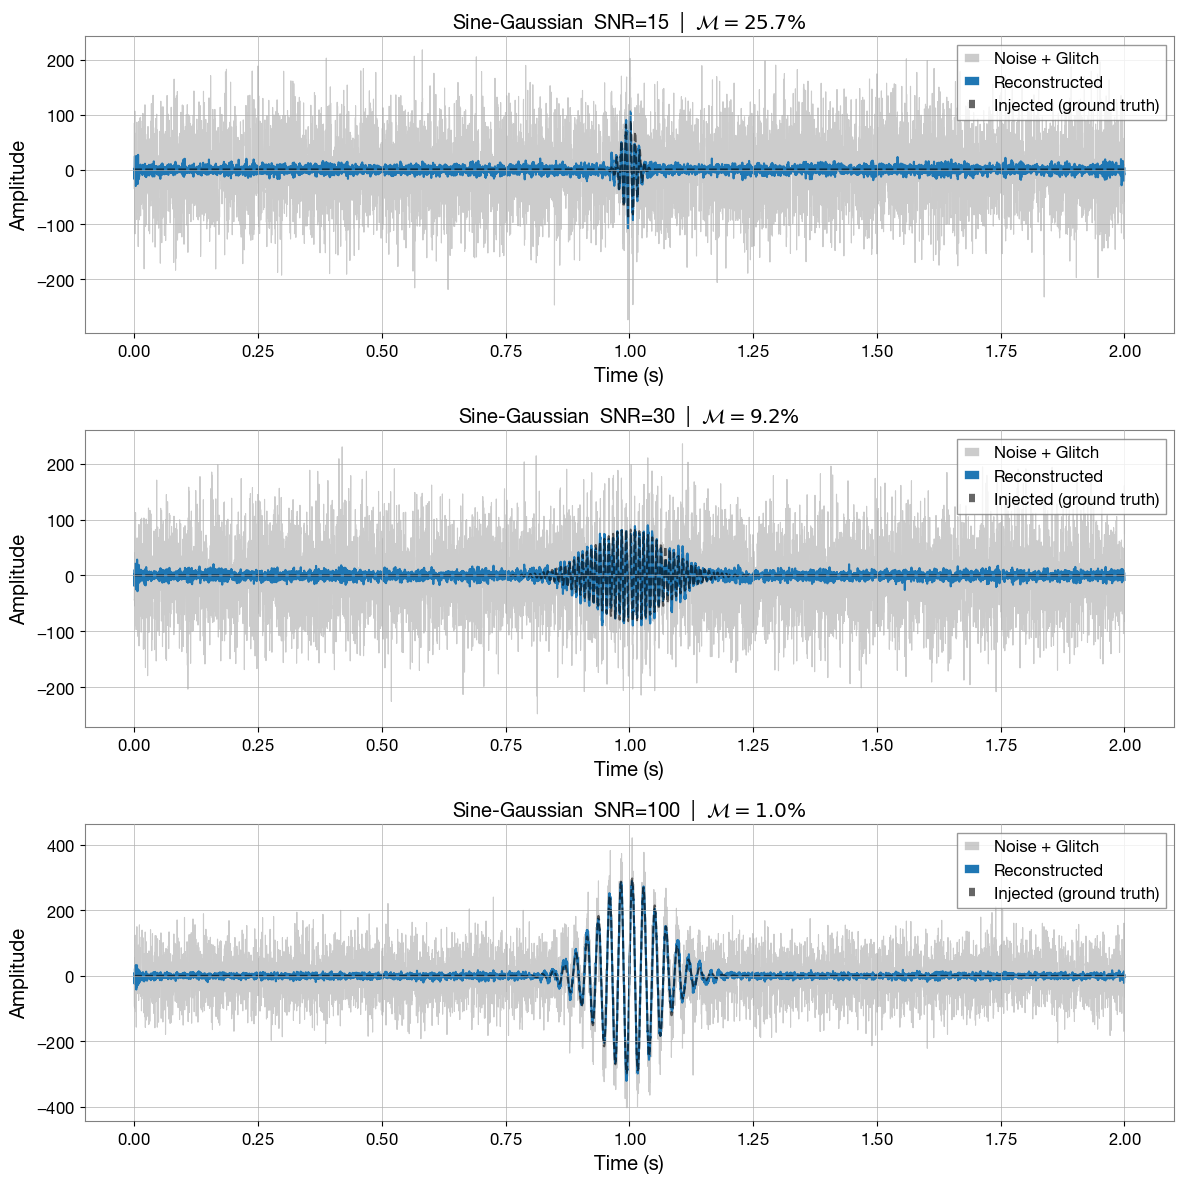

In [9]:
T_INJ = T / 2
SNR_VALUES = [15, 30, 100]

def overlap(a, b):
    """Normalised time-domain overlap (match) between two real signals.
    Equivalent to the PyCBC match on whitened data (flat PSD)."""
    return np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b))

fig, axes = plt.subplots(len(SNR_VALUES), 1, figsize=(12, 4 * len(SNR_VALUES)))
t_axis = np.linspace(0, T, LENGTH)

for ax, snr in zip(axes, SNR_VALUES):
    noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    
    # We set freq_max=256 when generating the sine-Gaussians for visualization purposes. This can be increased to the Nyquist frequency (i.e. freq_max=2048).
    _, wavelet = generate_sine_gaussian(duration=0.5, freq_max=256)
    wavelet = wavelet - np.mean(wavelet)
    wavelet = whitened_snr_scaling(wavelet, snr=snr)

    len_glitch = len(wavelet)
    id_start   = int(T_INJ * SAMPLE_RATE) - len_glitch // 2
    noisy      = noise.copy()
    noisy[id_start : id_start + len_glitch] += wavelet

    injected = np.zeros(LENGTH)
    injected[id_start : id_start + len_glitch] = wavelet

    reconstructed = reconstruct(noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    match    = overlap(injected, reconstructed)
    mismatch = 1.0 - match

    ax.plot(t_axis, noisy,         color="gray",  lw=0.8, alpha=0.4, label="Noise + Glitch")
    ax.plot(t_axis, reconstructed, color="C0",    lw=1.5, label="Reconstructed")
    ax.plot(t_axis, injected,      color="black", lw=1.5, alpha=0.6, linestyle="--", label="Injected (ground truth)")
    ax.set_title(
        f"Sine-Gaussian  SNR={snr}  |  "
        f"$\\mathcal{{M}} = {mismatch*100:.1f} \% $"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()
